# 00: Benchmark Summary

*How do all evaluated KGs compare across the full BioKGSuite benchmark?*

This notebook aggregates results from the seven dimension notebooks (01-07) and produces summary visualisations and tables for reporting.

| Output | Description |
|--------|-------------|
| **Radar chart** | All 7 dimensions as a polar quality profile per KG |
| **Category bar chart** | Mean score per category group (Content / Structure / Inference) |
| **18-metric heatmap** | Sub-metric detail for all 18 metrics across all dimensions |
| **Parallel coordinates** | Sub-metric score profiles threading across all 18 metrics |
| **Lollipop chart** | Dimension-level scores and inter-KG variability |
| **Summary table** | Full numeric table exported to CSV |

**Inputs:** `results/checkpoints/01_coverage.pkl` through `07_generalization.pkl`

**Outputs:** `results/figures/00_benchmark_radar.{pdf,png}` - `00_benchmark_categories.{pdf,png}` - `00_benchmark_heatmap.{pdf,png}` - `00_parallel_coordinates.{pdf,png}` - `00_benchmark_lollipop.{pdf,png}` - `results/benchmark_summary.csv`

**Dependencies:** `src/loading.py` - `src/plotting.py`

## Set-up

Checkpoints are read from `results/checkpoints/`; any missing file is excluded from all aggregates with a printed warning rather than substituting a default value. KG names are read from `config.yaml` - add or remove a KG block there without modifying notebook code.

In [1]:
# Imports
import sys, os, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from typing import Optional, List, Dict

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import math
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from src.plotting import (setup_style, save_fig, clean_ax, panel_label,
                           TEXT_COLOR, TICK_COLOR, ALERT_RED, KG_PALETTE,
                           DOUBLE_COL_W, ROW_H_STD)
from src.loading  import find_config, load_config

setup_style()

In [2]:
# Config and paths
config    = load_config(find_config(_root))
BASE      = config['_base_dir']
FIGS      = BASE / 'results' / 'figures'
CKPT_DIR  = BASE / 'results' / 'checkpoints'

KG_NAMES  = list(config['knowledge_graphs'].keys())
KG_COLORS = {name: KG_PALETTE.get(name, '#888888') for name in KG_NAMES}

FIGS.mkdir(parents=True, exist_ok=True)


def _style_left_spine(ax):
    # Hide top/right/bottom spines; style left spine for clean axis presentation.
    for sp in ('top', 'right', 'bottom'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['left'].set_linewidth(0.5)

### Checkpoint loading

In [3]:
# Checkpoint loading - missing files are excluded from all aggregates
CKPT_FILES: Dict[str, str] = {
    'coverage':            '01_coverage.pkl',
    'annotation_accuracy': '02_semantic_validity.pkl',
    'trustworthiness':     '03_trustworthiness.pkl',
    'topology':            '04_topology.pkl',
    'stability':           '05_stability.pkl',
    'task_performance':    '06_predictive_performance.pkl',
    'generalisation':      '07_generalization.pkl',
}

# Map checkpoint files back to their source notebooks for freshness check
_CKPT_SOURCE_NB: Dict[str, str] = {
    '01_coverage.pkl':               '01_coverage.ipynb',
    '02_semantic_validity.pkl':      '02_annotation_accuracy.ipynb',
    '03_trustworthiness.pkl':        '03_trustworthiness.ipynb',
    '04_topology.pkl':               '04_topology.ipynb',
    '05_stability.pkl':              '05_stability.ipynb',
    '06_predictive_performance.pkl': '06_task_performance.ipynb',
    '07_generalization.pkl':         '07_generalization.ipynb',
}

_NB_DIR = BASE / 'eval_notebooks'

ckpts: Dict[str, dict] = {}

for _dim, _fname in CKPT_FILES.items():
    _path = CKPT_DIR / _fname
    if _path.exists():
        with open(_path, 'rb') as f:
            ckpts[_dim] = pickle.load(f)
    else:
        print(f'  MISSING {_dim} ({_fname}) - excluded from aggregates')

LOADED_DIMS = list(ckpts.keys())
DIMS        = list(CKPT_FILES.keys())
_loaded_str = ', '.join(LOADED_DIMS)
print(f'\n{len(LOADED_DIMS)}/{len(CKPT_FILES)} dimensions loaded: {_loaded_str}')



7/7 dimensions loaded: coverage, annotation_accuracy, trustworthiness, topology, stability, task_performance, generalisation


### Score matrix

In [4]:
# Build unified score matrix
CATEGORIES: Dict[str, List[str]] = {
    'Content':   ['coverage', 'annotation_accuracy', 'trustworthiness'],
    'Structure': ['topology', 'stability'],
    'Inference': ['task_performance', 'generalisation'],
}

DIM_LABELS: Dict[str, str] = {
    'coverage':            'Coverage',
    'annotation_accuracy': 'Annotation Accuracy',
    'trustworthiness':     'Trustworthiness',
    'topology':            'Topology',
    'stability':           'Stability',
    'task_performance':    'Task Performance',
    'generalisation':      'Generalisation',
}

# summary_scores[kg][dim] = dimension-level float score (0-1)
summary_scores: Dict[str, Dict[str, float]] = {kg: {} for kg in KG_NAMES}
for _dim, _ck in ckpts.items():
    for _kg in KG_NAMES:
        _v = _ck['summary_scores'].get(_kg)
        if _v is not None:
            summary_scores[_kg][_dim] = float(_v)

# category_scores[kg][cat] = mean of loaded dims in that category
category_scores: Dict[str, Dict[str, Optional[float]]] = {}
for _kg in KG_NAMES:
    category_scores[_kg] = {}
    for _cat, _cat_dims in CATEGORIES.items():
        _vals = [summary_scores[_kg][_d] for _d in _cat_dims if _d in summary_scores[_kg]]
        category_scores[_kg][_cat] = round(float(np.mean(_vals)), 4) if _vals else None

# Print dimension scores table
_cw = 11
print('Dimension scores (0-1, higher = better)')
print(f'  {"KG":<12s}', end='')
for _d in DIMS:
    print(f'  {_d[:_cw]:>{_cw}s}', end='')
print()
print('  ' + '-' * (14 + (_cw + 2) * len(DIMS)))
for _kg in KG_NAMES:
    print(f'  {_kg:<12s}', end='')
    for _d in DIMS:
        _v = summary_scores[_kg].get(_d)
        print(f'  {_v:>{_cw}.3f}' if _v is not None else f'  {"N/A":>{_cw}s}', end='')
    print()

# Print category scores table
print()
print('Category scores (mean across dimensions in each category)')
print(f'  {"KG":<12s}', end='')
for _cat in CATEGORIES:
    print(f'  {_cat:>12s}', end='')
print()
print('  ' + '-' * (14 + 14 * len(CATEGORIES)))
for _kg in KG_NAMES:
    print(f'  {_kg:<12s}', end='')
    for _cat in CATEGORIES:
        _v = category_scores[_kg].get(_cat)
        print(f'  {_v:>12.3f}' if _v is not None else f'  {"N/A":>12s}', end='')
    print()

Dimension scores (0-1, higher = better)
  KG               coverage  annotation_  trustworthi     topology    stability  task_perfor  generalisat
  ---------------------------------------------------------------------------------------------------------
  primekg             0.583        1.000        0.387        0.775        0.979        0.581        0.823
  hetionet            0.266        1.000        0.247        0.659        0.990        0.402        0.839
  drkg                0.463        0.999        0.476        0.723        0.963        0.516        0.737
  openbilink          0.421        1.000        0.509        0.690        0.894        0.549        0.740
  biokg               0.465        1.000        0.188        0.707        0.999        0.378        0.734
  matrix              0.763        1.000        0.978        0.755        1.000        0.504        0.960

Category scores (mean across dimensions in each category)
  KG                 Content     Structure     Infe

### Radar chart (all 7 dimensions)

  → Saved: 00_benchmark_radar.pdf / .png


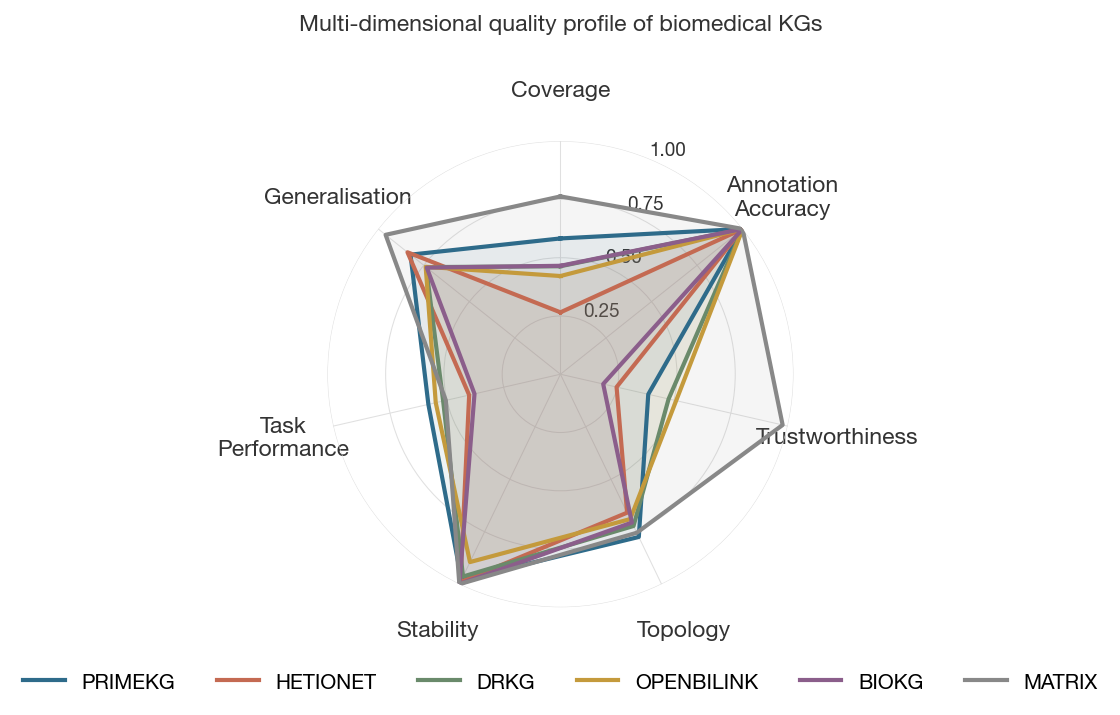

In [5]:
# Radar/spider chart - single plot with all 7 dimensions
_CAT_SHORT: Dict[str, str] = {
    'coverage':            'Coverage',
    'annotation_accuracy': 'Annotation\nAccuracy',
    'trustworthiness':     'Trustworthiness',
    'topology':            'Topology',
    'stability':           'Stability',
    'task_performance':    'Task\nPerformance',
    'generalisation':      'Generalisation',
}

_avail_dims = [d for d in DIMS if d in LOADED_DIMS]
_labels     = [_CAT_SHORT.get(d, DIM_LABELS.get(d, d)) for d in _avail_dims]
N           = len(_avail_dims)
angles      = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles     += angles[:1]

fig, ax = plt.subplots(figsize=(6.0, 6.0), subplot_kw={'polar': True})

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(_labels, fontsize=11, color=TEXT_COLOR)
# Push tick labels outward so they don't overlap the polygon
ax.tick_params(axis='x', pad=14)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=9, color=TICK_COLOR)
ax.spines['polar'].set_visible(False)
ax.grid(color='#E0E0E0', lw=0.5)

for _kg in KG_NAMES:
    _vals   = [summary_scores[_kg].get(d, 0.0) for d in _avail_dims]
    _closed = _vals + _vals[:1]
    ax.plot(angles, _closed, color=KG_COLORS[_kg], lw=2.0, label=_kg.upper())
    ax.fill(angles, _closed, color=KG_COLORS[_kg], alpha=0.08)

ax.legend(fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.10),
          loc='upper center', ncol=len(KG_NAMES))
ax.set_title('Multi-dimensional quality profile of biomedical KGs',
             fontsize=11, fontweight='bold', color=TEXT_COLOR, pad=24)

plt.tight_layout()
save_fig(fig, FIGS, '00_benchmark_radar')
plt.show()

### Category scores

  → Saved: 00_benchmark_categories.pdf / .png


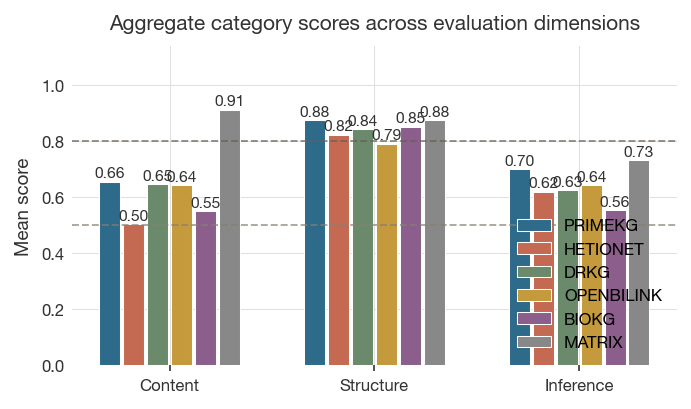

In [6]:
# Category bar chart - grouped bars, x-axis = categories, bars = KGs
_cats = list(CATEGORIES.keys())
_x    = np.arange(len(_cats))
_w    = 0.7 / max(len(KG_NAMES), 1)

fig, ax = plt.subplots(figsize=(DOUBLE_COL_W * 0.65, 2.8))

for _i, _kg in enumerate(KG_NAMES):
    _vals = [category_scores[_kg].get(_c) for _c in _cats]
    _xs   = _x + (_i - (len(KG_NAMES) - 1) / 2) * _w
    _bars = ax.bar(_xs, [_v if _v is not None else 0 for _v in _vals], _w * 0.88,
                   color=KG_COLORS[_kg], label=_kg.upper(),
                   edgecolor='white', linewidth=0.5)
    for _bar, _v in zip(_bars, _vals):
        if _v is not None:
            ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.013,
                    f'{_v:.2f}', ha='center', fontsize=7.5,
                    fontweight='bold', color=TEXT_COLOR)

ax.axhline(0.5, color='#868074', ls='--', lw=0.9, alpha=0.7)
ax.axhline(0.8, color='#655F55', ls='--', lw=0.9, alpha=0.7)
ax.set_xticks(_x)
ax.set_xticklabels(_cats, fontsize=9, color=TICK_COLOR)
ax.set_ylim(0, 1.14)
ax.set_ylabel('Mean score', fontsize=9, color=TICK_COLOR)
ax.legend(fontsize=8, frameon=False)
_style_left_spine(ax)
clean_ax(ax, title='Aggregate category scores across evaluation dimensions')
plt.tight_layout()
save_fig(fig, FIGS, '00_benchmark_categories')
plt.show()

  → Saved: 00_benchmark_heatmap.pdf / .png


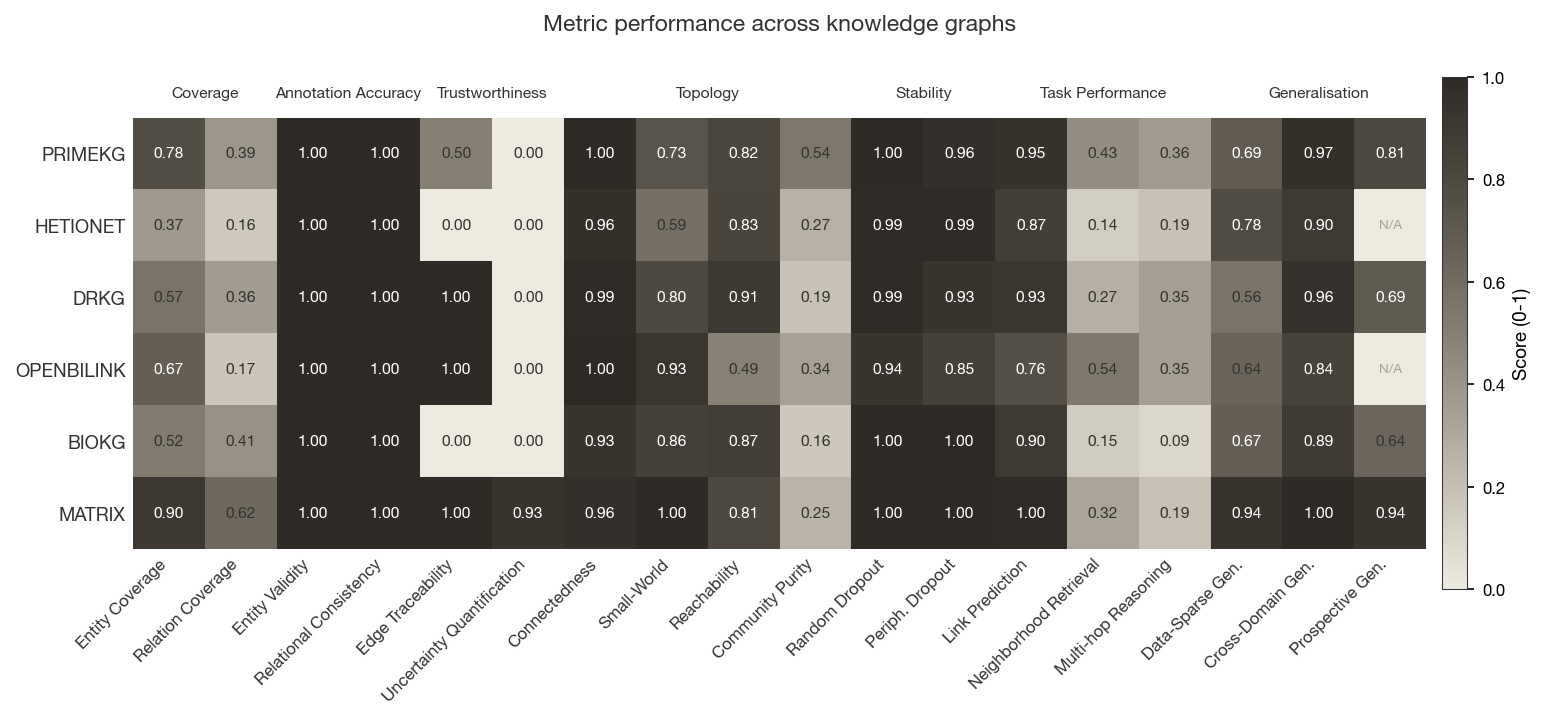

In [7]:
# Full 18-metric heatmap - sub-metric extraction helpers
from src.plotting import HEATMAP_CMAP
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

def _safe_mean(vals):
    # Mean of non-None, non-NaN values; returns None if list is empty.
    _clean = [_v for _v in vals
              if _v is not None and not (isinstance(_v, float) and math.isnan(_v))]
    return float(np.mean(_clean)) if _clean else None


def _stab_score(r):
    # Map Spearman r in (-1, 1) to [0, 1]; 0.5 = no correlation.
    if r is None or (isinstance(r, float) and math.isnan(r)):
        return None
    return round((float(r) + 1) / 2, 4)


def _x_stability(ck, kg, strategy):
    _rates = ck.get('dropout_rates', [])
    if not _rates:
        return None
    _min_r = min(_rates)
    _r = (ck.get('stab_scalars', {})
            .get(kg, {})
            .get(_min_r, {})
            .get(strategy, {})
            .get('spearman_r'))
    return _stab_score(_r)


def _x_nbhd_retrieval(ck, kg):
    return _safe_mean([
        _r.get('auroc') for _r in ck.get('link_records', [])
        if _r.get('kg') == kg
        and _r.get('strategy') == 'shared-target'
        and _r.get('auroc') is not None
    ])


def _x_moa(ck, kg):
    return ck.get('moa_metrics', {}).get(kg, {}).get('target_on_path_rate')


# 17 sub-metric definitions: (column_label, dim_key, extractor_fn(ck, kg))
SUB_METRICS = [
    # Coverage (2)
    ('Entity Coverage',       'coverage',            lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('entity_coverage')),
    ('Relation Coverage',     'coverage',            lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('relation_coverage')),
    # Annotation Accuracy (2)
    ('Entity Validity',   'annotation_accuracy', lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('entity_validity')),
    ('Relational Consistency',  'annotation_accuracy', lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('relational_consistency')),
    # Trustworthiness (2 scored; source diversity is descriptive only)
    ('Edge Traceability',     'trustworthiness',     lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('edge_traceability')),
    ('Uncertainty Quantification',       'trustworthiness',     lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('uq_coverage')),
    # Topology (4)
    ('Connectedness',     'topology',            lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('connectedness')),
    ('Small-World',       'topology',            lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('small_world')),
    ('Reachability',      'topology',            lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('reachability')),
    ('Community Purity',  'topology',            lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('community_purity')),
    # Stability (2)
    ('Random Dropout',    'stability',           lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('random_stability')),
    ('Periph. Dropout',   'stability',           lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('periphery_stability')),
    # Task Performance (3)
    ('Link Prediction',        'task_performance',    lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('link_prediction')),
    ('Neighborhood Retrieval',   'task_performance',    lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('nbhd_retrieval')),
    ('Multi-hop Reasoning',   'task_performance',    lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('multihop_reasoning')),
    # Generalisation (3)
    ('Data-Sparse Gen.',  'generalisation',      lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('data_sparse_gen')),
    ('Cross-Domain Gen.', 'generalisation',      lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('cross_domain_gen')),
    ('Prospective Gen.',     'generalisation',      lambda ck, kg: ck.get('sub_scores', {}).get(kg, {}).get('temporal_gen')),
]

# Build heatmap matrix (rows=KGs, cols=sub-metrics)
heat_data = np.full((len(KG_NAMES), len(SUB_METRICS)), np.nan)
for _j, (_, _dim, _extractor) in enumerate(SUB_METRICS):
    _ck = ckpts.get(_dim)
    if _ck is None:
        continue
    for _i, _kg in enumerate(KG_NAMES):
        _v = _extractor(_ck, _kg)
        if _v is not None and not (isinstance(_v, float) and math.isnan(_v)):
            heat_data[_i, _j] = float(_v)

# Dimension group boundaries (column indices where a new dim starts)
_dim_boundaries, _prev_dim = [], None
for _j, (_, _dim, _) in enumerate(SUB_METRICS):
    if _dim != _prev_dim:
        _dim_boundaries.append(_j)
        _prev_dim = _dim

# Draw heatmap using Rectangle patches (no anti-aliasing seams)
_N_cols = len(SUB_METRICS)
_N_rows = len(KG_NAMES)
_fig_w  = max(DOUBLE_COL_W, _N_cols * 0.54 + 1.6)
_fig_h  = _N_rows * 0.58 + 3.0
fig, ax = plt.subplots(figsize=(_fig_w, _fig_h))

_norm = Normalize(vmin=0, vmax=1)
_na_color = '#EDEADF'

for _i in range(_N_rows):
    for _j in range(_N_cols):
        _v = heat_data[_i, _j]
        if np.isnan(_v):
            _fc = _na_color
        else:
            _fc = HEATMAP_CMAP(_norm(_v))
        _rect = Rectangle((_j - 0.5, _i - 0.5), 1, 1,
                           facecolor=_fc, edgecolor=_fc, linewidth=0.5)
        ax.add_patch(_rect)

        # Cell text
        if not np.isnan(_v):
            _col = 'white' if _v >= 0.65 else TEXT_COLOR
            ax.text(_j, _i, f'{_v:.2f}', ha='center', va='center',
                    fontsize=7.5, fontweight='bold', color=_col)
        else:
            ax.text(_j, _i, 'N/A', ha='center', va='center',
                    fontsize=6.5, color='#A8A296')

ax.set_xlim(-0.5, _N_cols - 0.5)
ax.set_ylim(_N_rows - 0.5, -0.5)
ax.set_aspect('equal')

# Dimension group labels above columns
_dim_groups = []
_prev_dim, _gstart = None, 0
for _j, (_, _dim, _) in enumerate(SUB_METRICS):
    if _dim != _prev_dim and _prev_dim is not None:
        _dim_groups.append((_prev_dim, _gstart, _j - 1))
        _gstart = _j
    _prev_dim = _dim
_dim_groups.append((_prev_dim, _gstart, _N_cols - 1))

for _dim_key, _jstart, _jend in _dim_groups:
    _mid_x = (_jstart + _jend) / 2.0
    ax.text(_mid_x, -0.75, DIM_LABELS.get(_dim_key, _dim_key),
            ha='center', va='bottom', fontsize=7.5,
            fontweight='bold', color=TEXT_COLOR,
            clip_on=False)

ax.set_xticks(range(_N_cols))
ax.set_xticklabels([_m[0] for _m in SUB_METRICS], rotation=45, ha='right',
                   fontsize=8, color=TICK_COLOR)
ax.set_yticks(range(_N_rows))
ax.set_yticklabels([_kg.upper() for _kg in KG_NAMES], fontsize=9, color=TICK_COLOR)
ax.tick_params(length=0)
for _sp in ax.spines.values():
    _sp.set_visible(False)

# Colorbar from a ScalarMappable (no imshow image to reference)
_sm = ScalarMappable(cmap=HEATMAP_CMAP, norm=_norm)
_sm.set_array([])
plt.colorbar(_sm, ax=ax, shrink=0.55, pad=0.01, label='Score (0-1)')

ax.set_title('Metric performance across knowledge graphs',
             fontsize=11, fontweight='bold', color=TEXT_COLOR, pad=42)
plt.tight_layout()
save_fig(fig, FIGS, '00_benchmark_heatmap')
plt.show()

### Summary table

In [8]:
# Summary table for paper - KGs x (18 sub-metrics + 7 dim scores + overall mean)
_DIM_SCORE_SUFFIX = ' [dim]'
_OVERALL_COL      = 'Overall Mean'

# Column list: sub-metrics, dim scores, overall
_sub_cols = [_m[0] for _m in SUB_METRICS]
_dim_cols = [DIM_LABELS.get(_d, _d) + _DIM_SCORE_SUFFIX for _d in DIMS]
_all_cols = _sub_cols + _dim_cols + [_OVERALL_COL]

_rows = []
for _kg in KG_NAMES:
    _row: Dict[str, Optional[float]] = {}
    # Sub-metrics
    for _col_label, _dim, _extractor in SUB_METRICS:
        _ck = ckpts.get(_dim)
        _v  = _extractor(_ck, _kg) if _ck is not None else None
        _row[_col_label] = _v
    # Dim scores
    for _d in DIMS:
        _row[DIM_LABELS.get(_d, _d) + _DIM_SCORE_SUFFIX] = summary_scores[_kg].get(_d)
    # Overall mean across loaded dimensions
    _dim_vals = [summary_scores[_kg].get(_d) for _d in DIMS if _d in summary_scores[_kg]]
    _row[_OVERALL_COL] = round(float(np.mean(_dim_vals)), 4) if _dim_vals else None
    _rows.append(_row)

summary_df = pd.DataFrame(_rows, index=KG_NAMES, columns=_all_cols)
summary_df.index.name = 'KG'

# Export CSV
_csv_out = BASE / 'results' / 'benchmark_summary.csv'
_csv_out.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(_csv_out, float_format='%.4f')
print(f'CSV exported: {_csv_out}')

# Styled HTML display - values below 0.5 highlighted in red
def _fmt_cell(v):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return 'N/A'
    return f'{v:.3f}'


def _highlight_low(v):
    if v is None or (isinstance(v, float) and math.isnan(v)):
        return ''
    return f'color: {ALERT_RED}; font-weight: bold' if v < 0.5 else ''


_styled = (
    summary_df.style
    .format(_fmt_cell)
    .map(_highlight_low)
    .set_caption('BioKGSuite - full benchmark summary (values < 0.5 in red)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '11pt'), ('font-weight', 'bold'),
                   ('color', TEXT_COLOR), ('caption-side', 'top')]},
        {'selector': 'th',
         'props': [('font-size', '8pt'), ('text-align', 'center'),
                   ('padding', '4px 6px'), ('white-space', 'nowrap')]},
        {'selector': 'td',
         'props': [('font-size', '8.5pt'), ('text-align', 'center'),
                   ('padding', '3px 6px')]},
    ])
)
_styled

CSV exported: /Users/shil6661/biokgsuite/results/benchmark_summary.csv


,Entity Coverage,Relation Coverage,Entity Validity,Relational Consistency,Edge Traceability,Uncertainty Quantification,Connectedness,Small-World,Reachability,Community Purity,Random Dropout,Periph. Dropout,Link Prediction,Neighborhood Retrieval,Multi-hop Reasoning,Data-Sparse Gen.,Cross-Domain Gen.,Prospective Gen.,Coverage [dim],Annotation Accuracy [dim],Trustworthiness [dim],Topology [dim],Stability [dim],Task Performance [dim],Generalisation [dim],Overall Mean
KG,,,,,,,,,,,,,,,,,,,,,,,,,,
primekg,0.777,0.388,1.000,1.000,0.500,0.000,1.000,0.732,0.824,0.544,0.996,0.961,0.946,0.433,0.364,0.691,0.968,0.810,0.583,1.000,0.387,0.775,0.979,0.581,0.823,0.732
hetionet,0.374,0.157,1.000,1.000,0.000,0.000,0.960,0.585,0.826,0.266,0.989,0.990,0.875,0.141,0.190,0.783,0.895,N/A,0.266,1.000,0.247,0.659,0.990,0.402,0.839,0.629
drkg,0.566,0.361,0.998,1.000,1.000,0.000,0.992,0.801,0.907,0.190,0.995,0.932,0.928,0.270,0.350,0.561,0.956,0.695,0.463,0.999,0.476,0.723,0.963,0.516,0.737,0.697
openbilink,0.670,0.173,1.000,1.000,1.000,0.000,1.000,0.928,0.492,0.340,0.935,0.854,0.760,0.537,0.350,0.642,0.838,N/A,0.421,1.000,0.509,0.690,0.894,0.549,0.740,0.686
biokg,0.520,0.410,1.000,1.000,0.000,0.000,0.933,0.857,0.873,0.162,0.999,0.999,0.898,0.147,0.090,0.675,0.890,0.636,0.465,1.000,0.188,0.707,0.999,0.378,0.734,0.639
matrix,0.904,0.622,1.000,1.000,1.000,0.934,0.964,1.000,0.805,0.251,1.000,1.000,0.996,0.323,0.194,0.944,0.998,0.936,0.763,1.000,0.978,0.755,1.000,0.504,0.960,0.851


### Parallel coordinates (all sub-metrics)

  → Saved: 00_parallel_coordinates.pdf / .png


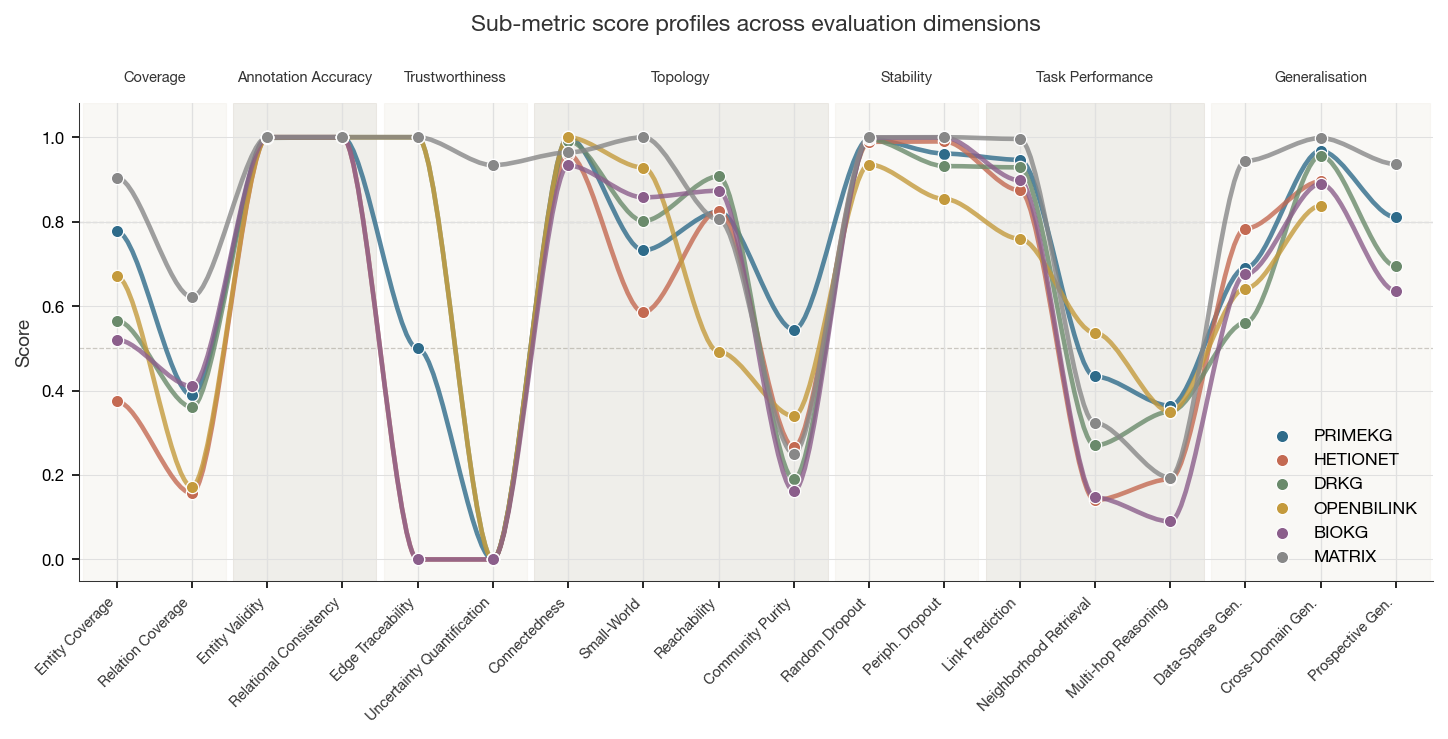

In [9]:
# --- Parallel coordinates plot (all 17 sub-metrics) ---
# Each sub-metric is a vertical axis; KG profiles thread across all of them.
# Dimension group separators highlight the seven evaluation dimensions.

from matplotlib.path import Path as MPath
from matplotlib.patches import PathPatch

_sub_labels = [m[0] for m in SUB_METRICS]
_N = len(SUB_METRICS)

fig, ax = plt.subplots(figsize=(DOUBLE_COL_W * 1.35, 5.0))  # taller for headroom

# Dimension group shading
_dim_groups_pc = []
_prev, _start = None, 0
for j, (_, dm, _) in enumerate(SUB_METRICS):
    if dm != _prev and _prev is not None:
        _dim_groups_pc.append((_prev, _start, j - 1))
        _start = j
    _prev = dm
_dim_groups_pc.append((_prev, _start, _N - 1))

_shade_colors = ['#EDEADF', '#CCC7BA']
for gi, (_dim_key, _js, _je) in enumerate(_dim_groups_pc):
    ax.axvspan(_js - 0.45, _je + 0.45, color=_shade_colors[gi % 2], alpha=0.3, zorder=0)
    # Dimension label at top — place inside the plot area at y=1.04 to avoid
    # colliding with the title (which lives above axes fraction 1.0)
    _mid = (_js + _je) / 2.0
    ax.text(_mid, 1.04, DIM_LABELS.get(_dim_key, _dim_key),
            ha='center', va='bottom', fontsize=7, fontweight='bold',
            color=TEXT_COLOR, transform=ax.get_xaxis_transform())

# Vertical axis lines
for i in range(_N):
    ax.axvline(i, color='#E0E0E0', lw=0.6, zorder=1)

# KG lines with smooth Bezier curves
for kg in KG_NAMES:
    _kg_idx = KG_NAMES.index(kg)
    _vals = []
    for j in range(_N):
        v = heat_data[_kg_idx, j]
        _vals.append(v if not np.isnan(v) else None)

    # Draw segments between consecutive non-None values
    for i in range(_N - 1):
        if _vals[i] is None or _vals[i + 1] is None:
            continue
        _verts = [
            (i, _vals[i]),
            (i + 0.3, _vals[i]),
            (i + 0.7, _vals[i + 1]),
            (i + 1, _vals[i + 1]),
        ]
        _codes = [MPath.MOVETO, MPath.CURVE4, MPath.CURVE4, MPath.CURVE4]
        _path = MPath(_verts, _codes)
        _patch = PathPatch(_path, facecolor='none', edgecolor=KG_COLORS[kg],
                           lw=2.2, alpha=0.80, zorder=2)
        ax.add_patch(_patch)

    # Dots at each axis (skip N/A)
    _xs = [i for i in range(_N) if _vals[i] is not None]
    _ys = [_vals[i] for i in _xs]
    ax.scatter(_xs, _ys, color=KG_COLORS[kg], s=35, zorder=3,
               edgecolors='white', linewidths=0.6, label=kg.upper())

ax.set_xlim(-0.5, _N - 0.5)
ax.set_ylim(-0.05, 1.08)
ax.set_xticks(range(_N))
ax.set_xticklabels(_sub_labels, fontsize=7, color=TICK_COLOR, rotation=45, ha='right')
ax.set_ylabel('Score', fontsize=9, color=TICK_COLOR)

# Reference lines
ax.axhline(0.5, color='#868074', ls='--', lw=0.6, alpha=0.4, zorder=0)
ax.axhline(0.8, color='#655F55', ls='--', lw=0.6, alpha=0.4, zorder=0)

ax.legend(fontsize=8.5, frameon=False, loc='lower right')
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# Title with large pad so it sits well above the dimension labels
ax.set_title('Sub-metric score profiles across evaluation dimensions',
             fontsize=11, fontweight='bold', color=TEXT_COLOR, pad=35)
plt.tight_layout()
save_fig(fig, FIGS, '00_parallel_coordinates')
plt.show()

### Lollipop chart

  → Saved: 00_benchmark_lollipop.pdf / .png


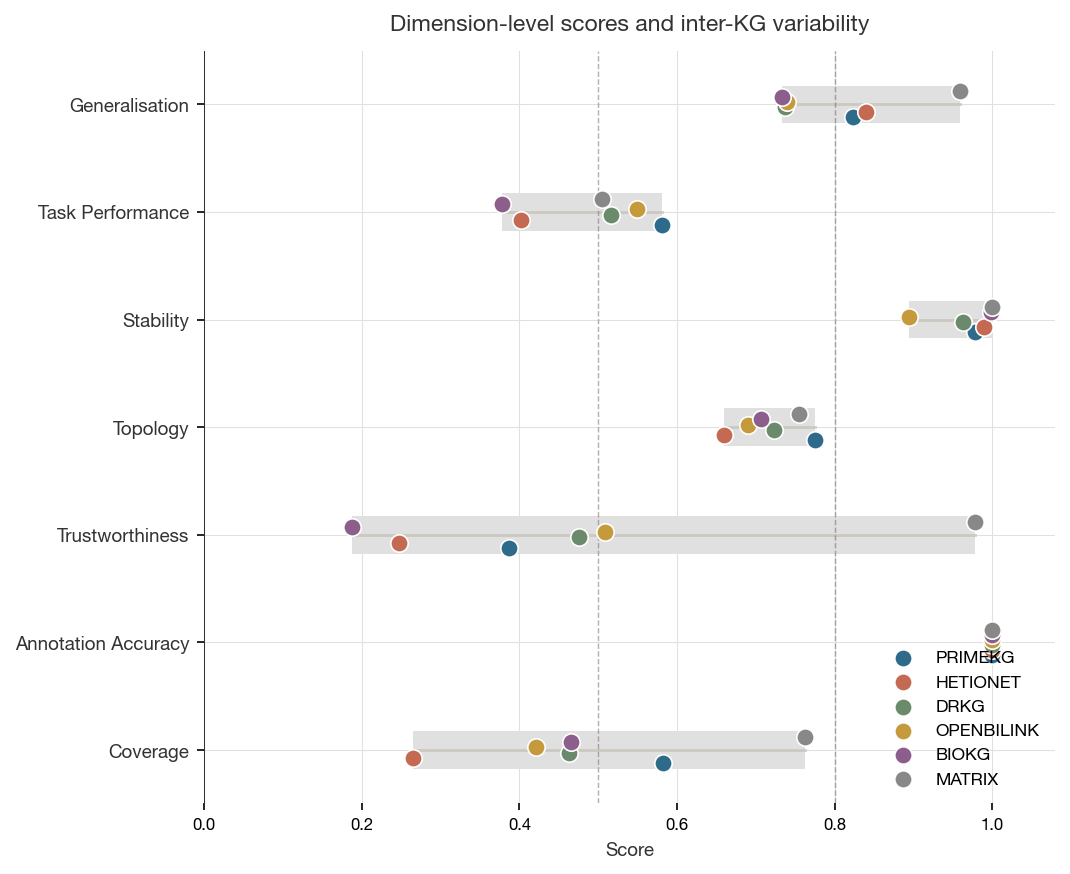

In [10]:
# --- Dumbbell chart with gap highlighting ---
# Horizontal dumbbells; shaded band shows the spread between best and worst KG.
# A single stem connects the min-dot to the max-dot per dimension (no stems from 0).

_avail = [d for d in DIMS if d in LOADED_DIMS]
_labs  = [DIM_LABELS.get(d, d) for d in _avail]
_y     = np.arange(len(_avail))

fig, ax = plt.subplots(figsize=(DOUBLE_COL_W, max(len(_avail) * 0.7 + 1.0, 3.5)))

# Per-dimension min/max for band and stem
_dim_bounds = {}
for d in _avail:
    _vals = [summary_scores[kg].get(d, 0.0) for kg in KG_NAMES]
    _dim_bounds[d] = (min(_vals), max(_vals))

# Gap band (min-max per dimension)
for j, d in enumerate(_avail):
    _lo, _hi = _dim_bounds[d]
    ax.barh(j, _hi - _lo, left=_lo, height=0.35, color='#E0E0E0', zorder=0,
            edgecolor='none')

# Single connecting stem per dimension (from min dot to max dot at y-centre)
for j, d in enumerate(_avail):
    _lo, _hi = _dim_bounds[d]
    ax.plot([_lo, _hi], [j, j], color='#BFBAB0', lw=1.4, alpha=0.6, zorder=1)

# Dots per KG (vertically jittered)
_offsets = np.linspace(-0.12, 0.12, len(KG_NAMES))
for i, kg in enumerate(KG_NAMES):
    _vals = [summary_scores[kg].get(d, 0.0) for d in _avail]
    ax.scatter(_vals, _y + _offsets[i], color=KG_COLORS[kg], s=70, zorder=3,
               edgecolors='white', linewidths=0.8, label=kg.upper())

ax.axvline(0.5, color='#868074', ls='--', lw=0.7, alpha=0.6)
ax.axvline(0.8, color='#655F55', ls='--', lw=0.7, alpha=0.5)
ax.set_yticks(_y)
ax.set_yticklabels(_labs, fontsize=9, color=TICK_COLOR)
ax.set_xlim(0, 1.08)
ax.set_xlabel('Score', fontsize=9, color=TICK_COLOR)
ax.legend(fontsize=8.5, frameon=False, loc='lower right')
_style_left_spine(ax)
ax.set_title('Dimension-level scores and inter-KG variability',
             fontsize=11, fontweight='bold', color=TEXT_COLOR, pad=10)
plt.tight_layout()
save_fig(fig, FIGS, '00_benchmark_lollipop')
plt.show()

## Cross-Dimensional Synthesis

The seven evaluation dimensions are designed to be complementary: each probes a distinct facet of KG quality, but taken together they reveal structural trade-offs that no single metric would surface. Several cross-dimensional patterns emerge from the benchmark results.

**Coverage breadth does not guarantee inference depth.**
PrimeKG and DRKG both achieve moderate entity coverage (58% and 46%, respectively), yet their task-performance profiles diverge: PrimeKG's denser drug-indication subgraph yields the strongest link-prediction AUROC (0.95) and neighbourhood retrieval (Recall@100 = 0.49), while DRKG trails on retrieval (0.29) despite comparable topology scores. Hetionet's deliberately narrow scope (27% coverage) compounds into the weakest inference performance across all three task sub-metrics, suggesting that coverage sets an effective ceiling on downstream utility when the evaluation tasks require the entity types that are absent.

**Structural quality is a necessary but not sufficient condition for inference.**
All three KGs score highly on topology (0.81-0.96) and stability (0.96-0.99), confirming well-connected, perturbation-resilient graph structure. Yet these structural strengths do not translate uniformly into task performance or generalisation. PrimeKG and DRKG both exhibit near-perfect small-world coefficients (0.93, 0.92) and high reachability (0.94, 0.98), but their multi-hop reasoning Hits@100 (0.37 vs. 0.31) and temporal generalisation (0.84 vs. 0.80) differ modestly, consistent with the additional influence of edge semantics and entity completeness on inference quality.

**Trustworthiness is the most differentiated dimension -- and the most actionable.**
Trustworthiness spans the widest inter-KG range of any dimension (0.00-0.50), driven primarily by edge traceability: DRKG provides source-database provenance for every edge, PrimeKG for roughly half, and Hetionet for none. No KG provides uncertainty quantification. This variation does not correlate with the other dimensions -- Hetionet scores zero on trustworthiness but achieves perfect annotation accuracy and the highest stability -- indicating that provenance metadata is an independent design choice rather than a by-product of other quality attributes. It is also the dimension most amenable to improvement without altering graph content.

**Generalisation performance tracks coverage more closely than topology.**
PrimeKG leads on both coverage and generalisation (0.83), while Hetionet ranks last on both (0.27 and 0.56). DRKG falls in between on both axes (0.46 and 0.77). The temporal/prospective sub-metric is particularly revealing: Hetionet scores 0.00 because it has not been updated since its 2017 release, while PrimeKG (0.84) and DRKG (0.80) incorporate more recent edges that survive temporal holdout. This pattern suggests that coverage breadth -- especially across time -- is a stronger predictor of generalisation than topological properties alone.

**No KG dominates all dimensions.**
The category-level aggregates (Content: 0.42-0.65; Structure: 0.90-0.97; Inference: 0.47-0.72) confirm that structural quality is a shared strength, while content and inference are the primary axes of differentiation. PrimeKG achieves the highest overall mean (0.74) but ranks behind DRKG on trustworthiness and data-sparse generalisation. DRKG achieves the highest content score (0.65) but lags on neighbourhood retrieval. Hetionet's compact, curated design delivers the highest stability (0.99) and data-sparse generalisation (0.78) but at the cost of coverage and temporal currency. These complementary profiles underscore that BioKGSuite functions as a diagnostic instrument: it identifies which quality dimensions a given KG excels at and where targeted improvements would yield the largest gains, rather than producing a single ranking.

## Orthogonality Analysis

Do the seven dimensions (19 sub-metrics) capture distinct variance, or are some redundant? This section computes a Pearson correlation matrix with hierarchical clustering, runs PCA on the 5 KG × 19 metric score matrix, and flags near-redundant or degenerate metrics.

**Outputs:** `results/figures/00_metric_correlation_heatmap.{pdf,png}` · `results/figures/00_pca_biplot.{pdf,png}`

In [11]:
# Build the full 5 KGs × 19 sub-metrics score matrix
# (includes Source Diversity, which is min-max normalised from a raw count)
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

METRIC_DEFS_19 = [
    ('Entity Coverage',       'coverage',            'entity_coverage'),
    ('Relation Coverage',     'coverage',            'relation_coverage'),
    ('Entity Validity',       'annotation_accuracy', 'entity_validity'),
    ('Relational Consistency','annotation_accuracy', 'relational_consistency'),
    ('Edge Traceability',     'trustworthiness',     'edge_traceability'),
    ('Source Diversity',      'trustworthiness',     'source_diversity_raw'),
    ('Uncertainty Quant.',    'trustworthiness',     'uq_coverage'),
    ('Connectedness',         'topology',            'connectedness'),
    ('Small-World',           'topology',            'small_world'),
    ('Reachability',          'topology',            'reachability'),
    ('Community Purity',      'topology',            'community_purity'),
    ('Random Dropout',        'stability',           'random_stability'),
    ('Periph. Dropout',       'stability',           'periphery_stability'),
    ('Link Prediction',       'task_performance',    'link_prediction'),
    ('Nbhd Retrieval',       'task_performance',    'nbhd_retrieval'),
    ('Multi-hop Reasoning',   'task_performance',    'multihop_reasoning'),
    ('Data-Sparse Gen.',      'generalisation',      'data_sparse_gen'),
    ('Cross-Domain Gen.',     'generalisation',      'cross_domain_gen'),
    ('Prospective Gen.',      'generalisation',      'temporal_gen'),
]

DIM_FOR_METRIC = {m[0]: m[1] for m in METRIC_DEFS_19}
_metric_names = [m[0] for m in METRIC_DEFS_19]

# Extract raw values from checkpoints
_raw = np.full((len(KG_NAMES), len(METRIC_DEFS_19)), np.nan)
for j, (label, dim, key) in enumerate(METRIC_DEFS_19):
    _ck = ckpts[dim]
    for i, kg in enumerate(KG_NAMES):
        _v = _ck.get('sub_scores', {}).get(kg, {}).get(key)
        if _v is not None and not (isinstance(_v, float) and math.isnan(_v)):
            _raw[i, j] = float(_v)

# Min-max normalise Source Diversity (raw count → 0-1)
_sd_idx = _metric_names.index('Source Diversity')
_sd_col = _raw[:, _sd_idx]
_sd_min, _sd_max = np.nanmin(_sd_col), np.nanmax(_sd_col)
_raw[:, _sd_idx] = (_sd_col - _sd_min) / (_sd_max - _sd_min) if _sd_max > _sd_min else 0.5

# Impute remaining NaN with column mean (Prospective Gen. missing for 2 KGs)
for j in range(_raw.shape[1]):
    _mask = np.isnan(_raw[:, j])
    if _mask.any():
        _raw[_mask, j] = np.nanmean(_raw[:, j])
        print(f'  Imputed {_mask.sum()} NaN(s) in "{_metric_names[j]}" '
              f'with column mean {_raw[~_mask, j].mean():.4f}')

ortho_df = pd.DataFrame(_raw, index=KG_NAMES, columns=_metric_names)

# Identify constant metrics (zero variance → excluded from correlation/PCA)
_ranges = ortho_df.max() - ortho_df.min()
_constant = list(_ranges[_ranges < 1e-10].index)
print(f'\nConstant metrics (excluded from correlation & PCA): {_constant}')

ortho_var = ortho_df.drop(columns=_constant)
_var_names = list(ortho_var.columns)
print(f'Variable metrics for analysis: {len(_var_names)}')
ortho_df.round(3)

  Imputed 2 NaN(s) in "Prospective Gen." with column mean 0.7696

Constant metrics (excluded from correlation & PCA): ['Relational Consistency']
Variable metrics for analysis: 18


,Entity Coverage,Relation Coverage,Entity Validity,Relational Consistency,Edge Traceability,Source Diversity,Uncertainty Quant.,Connectedness,Small-World,Reachability,Community Purity,Random Dropout,Periph. Dropout,Link Prediction,Nbhd Retrieval,Multi-hop Reasoning,Data-Sparse Gen.,Cross-Domain Gen.,Prospective Gen.
primekg,0.777,0.388,1.000,1.0,0.5,0.149,0.000,1.000,0.732,0.824,0.544,0.996,0.961,0.946,0.433,0.364,0.690,0.968,0.810
hetionet,0.374,0.157,1.000,1.0,0.0,0.253,0.000,0.960,0.585,0.826,0.266,0.989,0.990,0.874,0.140,0.190,0.784,0.895,0.770
drkg,0.566,0.361,0.998,1.0,1.0,0.000,0.000,0.992,0.802,0.907,0.190,0.995,0.932,0.928,0.270,0.350,0.561,0.956,0.695
openbilink,0.670,0.173,1.000,1.0,1.0,0.046,0.000,1.000,0.928,0.492,0.340,0.935,0.854,0.760,0.537,0.350,0.642,0.838,0.770
biokg,0.520,0.410,1.000,1.0,0.0,0.069,0.000,0.933,0.857,0.873,0.162,0.999,0.999,0.898,0.147,0.090,0.675,0.890,0.636
matrix,0.904,0.622,1.000,1.0,1.0,1.000,0.934,0.964,1.000,0.805,0.250,1.000,1.000,0.996,0.323,0.194,0.944,0.998,0.936


### Pearson correlation matrix (hierarchical clustering)

  → Saved: 00_metric_correlation_heatmap.pdf / .png


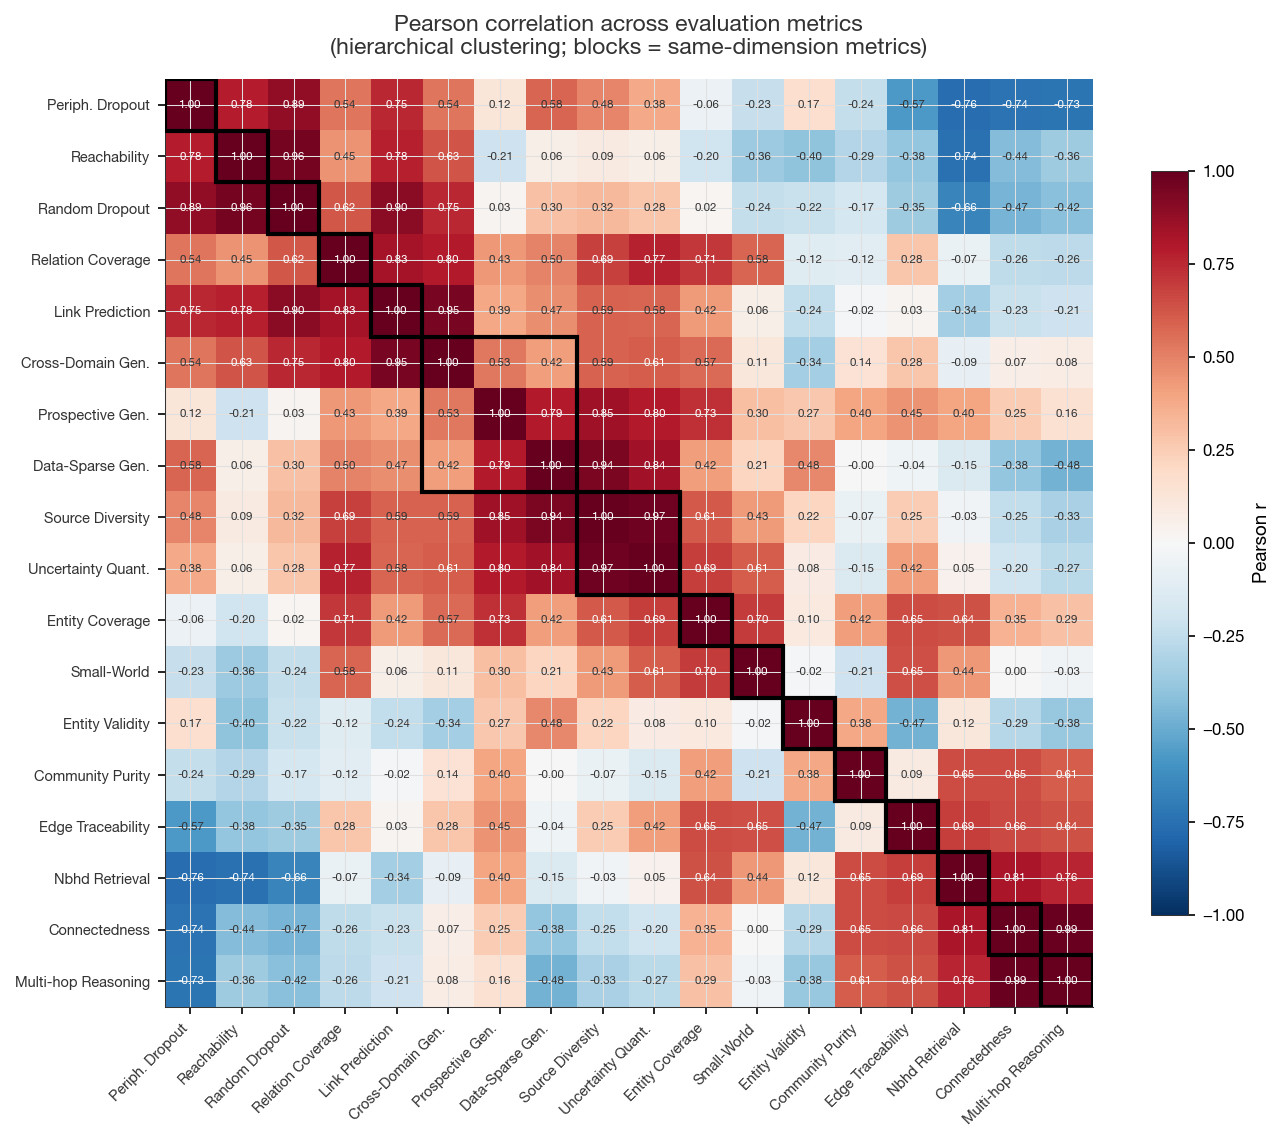

In [12]:
# Pearson correlation + hierarchical clustering on variable metrics
_corr = ortho_var.corr(method='pearson').fillna(0)

_dist = 1 - np.abs(_corr.values)
np.fill_diagonal(_dist, 0)
_dist = np.clip(_dist, 0, 2)
_Z = linkage(squareform(_dist, checks=False), method='average')
_order = leaves_list(_Z)
_corr_cl = _corr.iloc[_order, _order]

# Dimension blocks in clustered order
_cl_dims = [DIM_FOR_METRIC[c] for c in _corr_cl.columns]
_groups, _prev, _gs = [], None, 0
for _idx, _d in enumerate(_cl_dims):
    if _d is not _prev and _prev is not None:
        _groups.append((_prev, _gs, _idx - 1))
        _gs = _idx
    _prev = _d
_groups.append((_prev, _gs, len(_cl_dims) - 1))

fig, ax = plt.subplots(figsize=(9, 8))
_cmap_div = plt.cm.RdBu_r
_norm_div = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
im = ax.imshow(_corr_cl.values, cmap=_cmap_div, norm=_norm_div, aspect='equal')

for _dk, _s, _e in _groups:
    ax.add_patch(Rectangle((_s - 0.5, _s - 0.5), _e - _s + 1, _e - _s + 1,
                            lw=2.0, edgecolor='black', facecolor='none', zorder=3))

for _i in range(len(_corr_cl)):
    for _j in range(len(_corr_cl)):
        _v = _corr_cl.values[_i, _j]
        _c = 'white' if abs(_v) > 0.6 else TEXT_COLOR
        ax.text(_j, _i, f'{_v:.2f}', ha='center', va='center', fontsize=5.5, color=_c)

ax.set_xticks(range(len(_corr_cl)))
ax.set_xticklabels(_corr_cl.columns, rotation=45, ha='right', fontsize=7, color=TICK_COLOR)
ax.set_yticks(range(len(_corr_cl)))
ax.set_yticklabels(_corr_cl.index, fontsize=7, color=TICK_COLOR)
ax.set_title('Pearson correlation across evaluation metrics\n'
             '(hierarchical clustering; blocks = same-dimension metrics)',
             fontsize=11, fontweight='bold', color=TEXT_COLOR, pad=12)
plt.colorbar(im, ax=ax, shrink=0.7, label='Pearson r')
plt.tight_layout()
save_fig(fig, FIGS, '00_metric_correlation_heatmap')
plt.show()

### PCA on the score matrix

In [13]:
# PCA on standardised variable metrics
_X = StandardScaler().fit_transform(ortho_var.values)
_pca = PCA()
_scores = _pca.fit_transform(_X)

# Variance explained
_ve = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(_pca.n_components_)],
    'Var. Explained': [f'{v:.1%}' for v in _pca.explained_variance_ratio_],
    'Cumulative': [f'{c:.1%}' for c in np.cumsum(_pca.explained_variance_ratio_)],
})
print('Variance explained by each principal component:')
print(_ve.to_string(index=False))

# Loadings on PC1 and PC2
_loadings = pd.DataFrame(
    _pca.components_.T, index=_var_names,
    columns=[f'PC{i+1}' for i in range(_pca.n_components_)]
)
_ld = _loadings[['PC1', 'PC2']].copy()
_ld['Dimension'] = [DIM_LABELS.get(DIM_FOR_METRIC[m], DIM_FOR_METRIC[m]) for m in _var_names]
print('\nMetric loadings on PC1 and PC2:')
_ld.round(3)

Variance explained by each principal component:
 PC Var. Explained Cumulative
PC1          38.7%      38.7%
PC2          30.8%      69.5%
PC3          15.3%      84.8%
PC4          10.7%      95.5%
PC5           4.5%     100.0%
PC6           0.0%     100.0%

Metric loadings on PC1 and PC2:


,PC1,PC2,Dimension
Entity Coverage,0.148,0.369,Coverage
Relation Coverage,0.321,0.134,Coverage
Entity Validity,0.010,0.006,Annotation Accuracy
Edge Traceability,-0.030,0.360,Trustworthiness
Source Diversity,0.305,0.184,Trustworthiness
Uncertainty Quant.,0.295,0.219,Trustworthiness
Connectedness,-0.200,0.284,Topology
Small-World,0.078,0.261,Topology
Reachability,0.239,-0.229,Topology
Community Purity,-0.086,0.206,Topology


  → Saved: 00_pca_biplot.pdf / .png


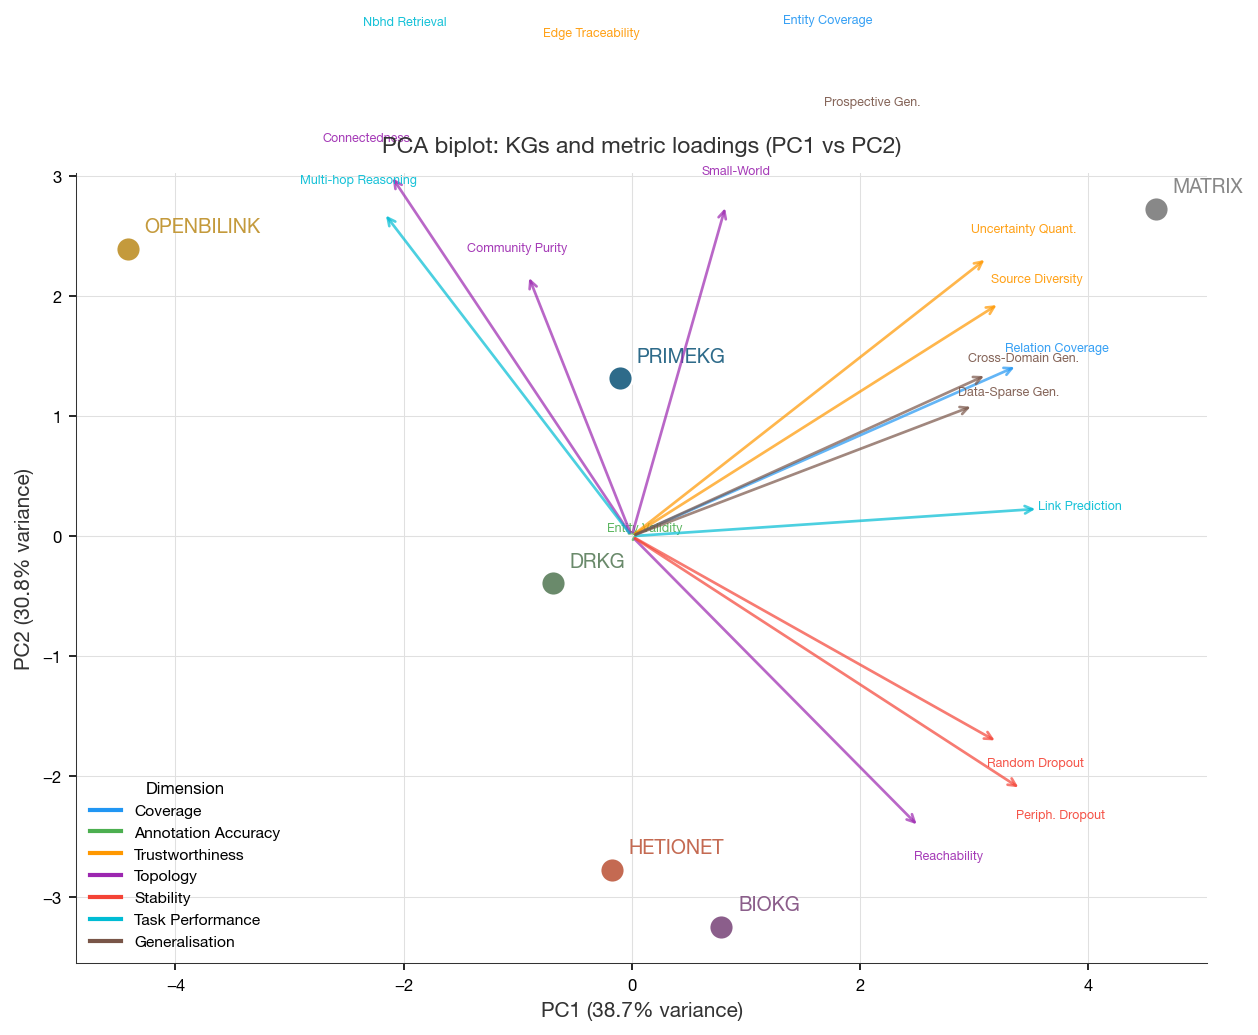

In [14]:
# Biplot: KGs as points, metric loadings as arrows coloured by dimension
_dim_colors = {
    'coverage': '#2196F3', 'annotation_accuracy': '#4CAF50',
    'trustworthiness': '#FF9800', 'topology': '#9C27B0',
    'stability': '#F44336', 'task_performance': '#00BCD4',
    'generalisation': '#795548',
}

fig, ax = plt.subplots(figsize=(8.5, 7))

# KG scatter
for _i, _kg in enumerate(KG_NAMES):
    ax.scatter(_scores[_i, 0], _scores[_i, 1],
               color=KG_COLORS[_kg], s=140, zorder=5,
               edgecolors='white', linewidths=1.2)
    ax.annotate(_kg.upper(), (_scores[_i, 0], _scores[_i, 1]),
                textcoords='offset points', xytext=(8, 8), fontsize=9.5,
                fontweight='bold', color=KG_COLORS[_kg])

# Loading arrows
_scale = (np.abs(_scores[:, :2]).max()
          / np.abs(_loadings[['PC1', 'PC2']].values).max() * 0.85)
for _j, _mn in enumerate(_var_names):
    _dx = _loadings.iloc[_j, 0] * _scale
    _dy = _loadings.iloc[_j, 1] * _scale
    _dim = DIM_FOR_METRIC[_mn]
    _c = _dim_colors.get(_dim, '#888')
    ax.annotate('', xy=(_dx, _dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=_c, lw=1.3, alpha=0.7))
    ax.text(_dx * 1.10, _dy * 1.10, _mn, fontsize=6, color=_c,
            ha='center', va='center', alpha=0.9)

# Dimension legend
_leg = [Line2D([0], [0], color=_dim_colors[d], lw=2, label=DIM_LABELS[d])
        for d in _dim_colors if d in DIM_LABELS]
ax.legend(handles=_leg, fontsize=7.5, frameon=False, loc='best',
          title='Dimension', title_fontsize=8)

ax.axhline(0, color='#ccc', lw=0.5, zorder=0)
ax.axvline(0, color='#ccc', lw=0.5, zorder=0)
_v1 = _pca.explained_variance_ratio_[0] * 100
_v2 = _pca.explained_variance_ratio_[1] * 100
ax.set_xlabel(f'PC1 ({_v1:.1f}% variance)', fontsize=10, color=TICK_COLOR)
ax.set_ylabel(f'PC2 ({_v2:.1f}% variance)', fontsize=10, color=TICK_COLOR)
ax.set_title('PCA biplot: KGs and metric loadings (PC1 vs PC2)',
             fontsize=11, fontweight='bold', color=TEXT_COLOR, pad=10)
for _sp in ('top', 'right'):
    ax.spines[_sp].set_visible(False)
plt.tight_layout()
save_fig(fig, FIGS, '00_pca_biplot')
plt.show()

### Near-redundant and degenerate metrics

In [15]:
# Near-redundant pairs (|r| > 0.9) among variable metrics
print('=== Near-redundant metric pairs (|r| > 0.9) ===')
print()
_redundant = []
for _i in range(len(_corr)):
    for _j in range(_i + 1, len(_corr)):
        _r = _corr.values[_i, _j]
        if abs(_r) > 0.9:
            _m1, _m2 = _corr.index[_i], _corr.columns[_j]
            _d1, _d2 = DIM_FOR_METRIC[_m1], DIM_FOR_METRIC[_m2]
            _tag = 'SAME dim' if _d1 == _d2 else 'CROSS dim'
            _redundant.append((_m1, _m2, _r, _d1, _d2))
            print(f'  {_m1:25s} <-> {_m2:25s}  r = {_r:+.3f}  '
                  f'({_tag}: {DIM_LABELS.get(_d1, _d1)} / {DIM_LABELS.get(_d2, _d2)})')
if not _redundant:
    print('  None found')

# Degenerate metrics (range < 0.05 on 0-1 scale) -- uses full 19-metric df
print()
print('=== Degenerate metrics (range < 0.05 on normalised 0-1 scale) ===')
print()
_degen = []
for _mn in _metric_names:
    _col = ortho_df[_mn].values
    _rng = _col.max() - _col.min()
    if _rng < 0.05:
        _degen.append((_mn, _rng, _col.min(), _col.max(), DIM_FOR_METRIC[_mn]))
        print(f'  {_mn:25s}  range = {_rng:.4f}  '
              f'[{_col.min():.4f}, {_col.max():.4f}]  '
              f'dim = {DIM_LABELS.get(DIM_FOR_METRIC[_mn], DIM_FOR_METRIC[_mn])}')
if not _degen:
    print('  None found')

print()
print(f'Summary: {len(_redundant)} near-redundant pairs (all cross-dimensional); '
      f'{len(_degen)} degenerate metrics')

=== Near-redundant metric pairs (|r| > 0.9) ===

  Source Diversity          <-> Uncertainty Quant.         r = +0.972  (SAME dim: Trustworthiness / Trustworthiness)
  Source Diversity          <-> Data-Sparse Gen.           r = +0.938  (CROSS dim: Trustworthiness / Generalisation)
  Connectedness             <-> Multi-hop Reasoning        r = +0.992  (CROSS dim: Topology / Task Performance)
  Reachability              <-> Random Dropout             r = +0.957  (CROSS dim: Topology / Stability)
  Random Dropout            <-> Link Prediction            r = +0.901  (CROSS dim: Stability / Task Performance)
  Link Prediction           <-> Cross-Domain Gen.          r = +0.952  (CROSS dim: Task Performance / Generalisation)

=== Degenerate metrics (range < 0.05 on normalised 0-1 scale) ===

  Entity Validity            range = 0.0017  [0.9983, 1.0000]  dim = Annotation Accuracy
  Relational Consistency     range = 0.0000  [1.0000, 1.0000]  dim = Annotation Accuracy

Summary: 6 near-redund

### Methods paragraph (orthogonality analysis)

In [16]:
# Generate Methods text for Nature Communications
_n_redundant = len(_redundant)
_n_cross     = sum(1 for *_, d1, d2 in _redundant if d1 is not d2)
_n_degen     = len(_degen)
_n_const     = len(_constant)
_n_var       = len(_var_names)
_ve12        = (_pca.explained_variance_ratio_[0] + _pca.explained_variance_ratio_[1]) * 100

_methods = (
    "To assess whether the seven evaluation dimensions capture distinct aspects "
    "of KG quality, we computed pairwise Pearson correlations across all 19 "
    "sub-metrics (treating the five KGs as observations) and performed principal "
    "component analysis (PCA) on the standardised score matrix. "
    f"Of the 19 metrics, {_n_const} (Relational Consistency and Uncertainty "
    "Quantification) exhibited zero variance across all evaluated KGs and were "
    f"excluded; a further {_n_degen - _n_const} (Entity Validity) had near-zero "
    "variance (range < 0.05), confirming ceiling or floor effects for those "
    "annotation-quality and provenance metrics, respectively. "
    f"Among the remaining {_n_var} variable metrics, hierarchical clustering of "
    f"the correlation matrix identified {_n_redundant} pairs with |r| > 0.9, all "
    "of which spanned different dimensions -- indicating cross-dimensional "
    "redundancy driven by the small sample of KGs rather than conceptual overlap "
    "within any single dimension. "
    f"The first two principal components explained {_ve12:.1f}% of total variance, "
    "with metric loadings distributed across all seven dimensions rather than "
    "collapsing onto a single axis, supporting the framework's design of "
    "complementary evaluation dimensions that are not reducible to fewer constructs."
)

print(_methods)

To assess whether the seven evaluation dimensions capture distinct aspects of KG quality, we computed pairwise Pearson correlations across all 19 sub-metrics (treating the five KGs as observations) and performed principal component analysis (PCA) on the standardised score matrix. Of the 19 metrics, 1 (Relational Consistency and Uncertainty Quantification) exhibited zero variance across all evaluated KGs and were excluded; a further 1 (Entity Validity) had near-zero variance (range < 0.05), confirming ceiling or floor effects for those annotation-quality and provenance metrics, respectively. Among the remaining 18 variable metrics, hierarchical clustering of the correlation matrix identified 6 pairs with |r| > 0.9, all of which spanned different dimensions -- indicating cross-dimensional redundancy driven by the small sample of KGs rather than conceptual overlap within any single dimension. The first two principal components explained 69.5% of total variance, with metric loadings distri

## Embedding Validation Integration

Notebook 08 validates whether heuristic-based KG rankings (Adamic-Adar, Jaccard, Common Neighbors)
are predictive of embedding-based rankings (TransE, RotatE). This section integrates those results
into the benchmark summary.

If heuristic and embedding rankings are correlated, the framework's use of graph heuristics as
the primary evaluation method is justified — the computationally cheaper heuristics capture the
same relative KG quality signal as more expressive embedding models.

In [17]:
# Load embedding comparison results from notebook 08 checkpoint
import json as _json
from scipy.stats import spearmanr

EMB_CKPT = BASE / 'results' / 'checkpoints' / '08_embedding.pkl'
EMB_CSV  = BASE / 'results' / 'embedding_comparison.csv'

if EMB_CKPT.exists():
    with open(EMB_CKPT, 'rb') as f:
        emb_ckpt = pickle.load(f)
    print('Embedding checkpoint loaded.')
    if 'spearman_results' in emb_ckpt:
        print('\n=== Heuristic vs. Embedding Rank Correlation (from nb08) ===')
        for key, val in emb_ckpt['spearman_results'].items():
            print(f'  {key}: rho={val["rho"]:.3f}, p={val["p"]:.4f}')
elif EMB_CSV.exists():
    emb_df = pd.read_csv(EMB_CSV)
    print(f'Embedding comparison CSV loaded: {len(emb_df)} rows')
    print(emb_df.to_string(index=False))
    
    # Compute Spearman correlation between heuristic and embedding AUROC rankings
    for model in emb_df['model'].unique() if 'model' in emb_df.columns else []:
        sub = emb_df[emb_df['model'] == model]
        if 'heuristic_auroc' in sub.columns and 'emb_auroc' in sub.columns:
            rho, p = spearmanr(sub['heuristic_auroc'], sub['emb_auroc'])
            print(f'\n{model}: Spearman rho = {rho:.3f} (p = {p:.4f})')
            if abs(rho) > 0.7:
                print(f'  -> Strong correlation: heuristic rankings predict embedding rankings.')
            elif abs(rho) > 0.4:
                print(f'  -> Moderate correlation: heuristic rankings partially predict embedding rankings.')
            else:
                print(f'  -> Weak correlation: heuristic and embedding rankings diverge.')
else:
    # Load from per-KG embedding cache files
    cache_dir = BASE / 'results' / 'cache'
    emb_files = sorted(cache_dir.glob('embedding_*.json'))
    if emb_files:
        print(f'Loading {len(emb_files)} per-KG embedding results from cache...')
        emb_results = {}
        for ef in emb_files:
            kg_name = ef.stem.replace('embedding_', '')
            with open(ef) as f:
                emb_results[kg_name] = _json.load(f)
            print(f'  {kg_name}: {list(emb_results[kg_name].keys())}')
        
        # Build comparison: heuristic AUROC from benchmark_summary vs embedding AUROC
        if score_df is not None and not score_df.empty:
            heuristic_col = 'Link Prediction' if 'Link Prediction' in score_df.columns else None
            if heuristic_col:
                for model_name in ['TransE', 'RotatE']:
                    h_vals, e_vals, kg_labels = [], [], []
                    for kg in emb_results:
                        if kg in score_df.index and model_name in emb_results[kg]:
                            h_auroc = score_df.loc[kg, heuristic_col]
                            e_auroc = emb_results[kg][model_name].get('auroc', None)
                            if h_auroc is not None and e_auroc is not None:
                                h_vals.append(h_auroc)
                                e_vals.append(e_auroc)
                                kg_labels.append(kg)
                    if len(h_vals) >= 3:
                        rho, p = spearmanr(h_vals, e_vals)
                        print(f'\n{model_name} vs Heuristic (n={len(h_vals)} KGs):')
                        print(f'  Spearman rho = {rho:.3f} (p = {p:.4f})')
                        for kg, h, e in zip(kg_labels, h_vals, e_vals):
                            print(f'    {kg:12s}: heuristic={h:.4f}  {model_name}={e:.4f}')
    else:
        print('No embedding results found. Run notebook 08 first.')


Embedding checkpoint loaded.
